In [1]:
import os
import numpy as np
import pandas as pd

In [9]:
ablation_type = "unbalancedness"
file_dir = f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_{ablation_type}"
files = os.listdir(file_dir)

In [10]:
files[2]

'distinctive-haze-13_Donor1_M-CSF_3_metrics.csv'

In [11]:
len(files)

1130

In [12]:
5 * 24

120

In [13]:
files[0]

'brisk-night-106_Donor1_IFN-omega_33_metrics.csv'

In [14]:
np.unique([el.split("_")[-2] for el in files], return_counts=True)

(array(['17', '2', '3', '33', '5', '65', '81', '9'], dtype='<U2'),
 array([120, 130, 140, 150, 150, 150, 150, 140]))

In [15]:
dfs = []
for f in files:
    df_tmp = pd.read_csv(os.path.join(file_dir, f), index_col=0).T
    df_tmp["num_cytokine_in_train"] = f.split("_")[-2]
    dfs.append(df_tmp)

In [16]:
df = pd.concat(dfs)

In [17]:
df.head()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_B Intermediate/Memory,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,...,deg_decoded_r_squared_pDC,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train,ablation_value,num_cytokine_in_train,decoded_r_squared_NKT,e_distance_NKT,deg_decoded_r_squared_NKT
Donor1_IFN-omega,0.890600996358054,46.96895597180911,0.612500148160117,0.9262182116508484,0.904599130153656,0.9528859853744507,0.8992172479629517,0.9703304767608643,0.9452691078186035,0.9538146257400513,...,-0.13772261142730713,0.9665265083312988,13.442556965939161,brisk-night-106,33,0.8,33,NaN,NaN,NaN
Donor1_ADSF,0.8906185229619344,47.39303607925893,0.5917292634646097,0.9175859689712524,0.9387878179550171,0.9353325366973877,0.9649234414100647,0.9496013522148132,0.9550364017486572,0.9520809054374695,...,-0.13424408435821533,0.9523726105690002,25.95961451388598,grateful-darkness-27,33,1.0,33,0.8500686287879944,63.766446205803504,0.748666524887085
Donor1_M-CSF,0.8734262069066365,33.65863491905579,0.665224015712738,0.9417669773101807,0.9147958159446716,0.9500333666801453,0.9360501170158386,0.9655945301055908,0.9586095809936523,0.963899552822113,...,-0.18812096118927002,0.9712609052658081,4.97709705623879,distinctive-haze-13,3,1.0,3,0.5908240079879761,60.84596605844217,0.5679186582565308
Donor1_CD27L,0.8805611729621887,58.600274732645104,0.6503951032956441,0.9019891619682312,0.922932505607605,0.9450837969779968,0.9549902081489563,0.9428751468658447,0.9487492442131042,0.921222984790802,...,-0.3818931579589844,0.94557124376297,30.250244883751634,warm-sun-7,17,0.9,17,0.8349535465240479,73.74025007622424,0.7553753852844238
Donor1_IFN-omega,0.9027868892465319,43.49106466727885,0.682635132755552,0.9337209463119507,0.9069772958755493,0.9569589495658875,0.9253630638122559,0.9760769605636597,0.947973906993866,0.9629009962081909,...,0.2124115228652954,0.9765651822090149,7.403147415148965,brisk-snowball-80,81,0.9,81,NaN,NaN,NaN


In [18]:
ct = pd.crosstab(df["ablation_value"], df["num_cytokine_in_train"])
ct


num_cytokine_in_train,17,2,3,33,5,65,81,9
ablation_value,,,,,,,,
0.8,10,30,30,30,30,30,30,30
0.9,30,30,30,30,30,30,30,20
0.95,30,20,30,30,30,30,30,30
0.99,20,30,20,30,30,30,30,30
1.0,30,20,30,30,30,30,30,30


In [20]:
df.head()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_B Intermediate/Memory,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,...,deg_decoded_r_squared_pDC,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train,ablation_value,num_cytokine_in_train,decoded_r_squared_NKT,e_distance_NKT,deg_decoded_r_squared_NKT
Donor1_IFN-omega,0.890600996358054,46.96895597180911,0.612500148160117,0.9262182116508484,0.904599130153656,0.9528859853744507,0.8992172479629517,0.9703304767608643,0.9452691078186035,0.9538146257400513,...,-0.13772261142730713,0.9665265083312988,13.442556965939161,brisk-night-106,33,0.8,33,NaN,NaN,NaN
Donor1_ADSF,0.8906185229619344,47.39303607925893,0.5917292634646097,0.9175859689712524,0.9387878179550171,0.9353325366973877,0.9649234414100647,0.9496013522148132,0.9550364017486572,0.9520809054374695,...,-0.13424408435821533,0.9523726105690002,25.95961451388598,grateful-darkness-27,33,1.0,33,0.8500686287879944,63.766446205803504,0.748666524887085
Donor1_M-CSF,0.8734262069066365,33.65863491905579,0.665224015712738,0.9417669773101807,0.9147958159446716,0.9500333666801453,0.9360501170158386,0.9655945301055908,0.9586095809936523,0.963899552822113,...,-0.18812096118927002,0.9712609052658081,4.97709705623879,distinctive-haze-13,3,1.0,3,0.5908240079879761,60.84596605844217,0.5679186582565308
Donor1_CD27L,0.8805611729621887,58.600274732645104,0.6503951032956441,0.9019891619682312,0.922932505607605,0.9450837969779968,0.9549902081489563,0.9428751468658447,0.9487492442131042,0.921222984790802,...,-0.3818931579589844,0.94557124376297,30.250244883751634,warm-sun-7,17,0.9,17,0.8349535465240479,73.74025007622424,0.7553753852844238
Donor1_IFN-omega,0.9027868892465319,43.49106466727885,0.682635132755552,0.9337209463119507,0.9069772958755493,0.9569589495658875,0.9253630638122559,0.9760769605636597,0.947973906993866,0.9629009962081909,...,0.2124115228652954,0.9765651822090149,7.403147415148965,brisk-snowball-80,81,0.9,81,NaN,NaN,NaN


In [19]:
ct = pd.crosstab(df["ablation_value"], df["num_cytokine_in_train"])
ct.sum(axis=1)


ablation_value
0.8     220
0.9     230
0.95    230
0.99    220
1.0     230
dtype: int64

In [18]:
df["mean_decoded_r_sq_per_cell_type"] = df["mean_decoded_r_sq_per_cell_type"].astype("float")
df["ood_e_distance"] = df["ood_e_distance"].astype("float")

In [19]:
df_grouped = df[["ablation_value", "mean_decoded_r_sq_per_cell_type", "ood_e_distance"]].groupby("ablation_value")[["mean_decoded_r_sq_per_cell_type", "ood_e_distance"]].mean()

In [20]:
df_grouped

,mean_decoded_r_sq_per_cell_type,ood_e_distance
ablation_value,,
0.8,0.889171,17.748652
0.9,0.888876,16.975109
0.95,0.885645,18.812346
0.99,0.887709,17.380828
1.0,0.888851,17.874179


In [21]:
import seaborn as sns

<Axes: xlabel='ablation_value', ylabel='ood_e_distance'>

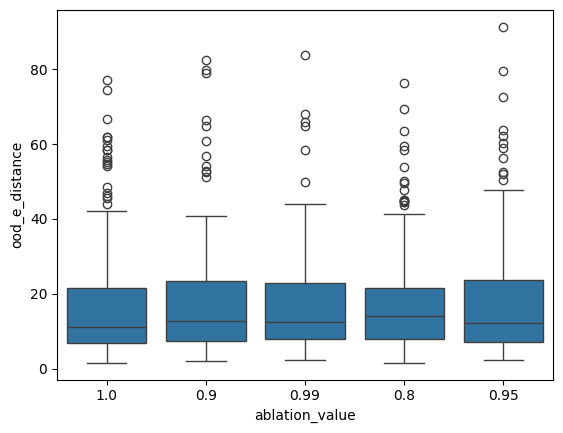

In [22]:
sns.boxplot(df, x="ablation_value", y="ood_e_distance")

<Axes: xlabel='ablation_value', ylabel='mean_decoded_r_sq_per_cell_type'>

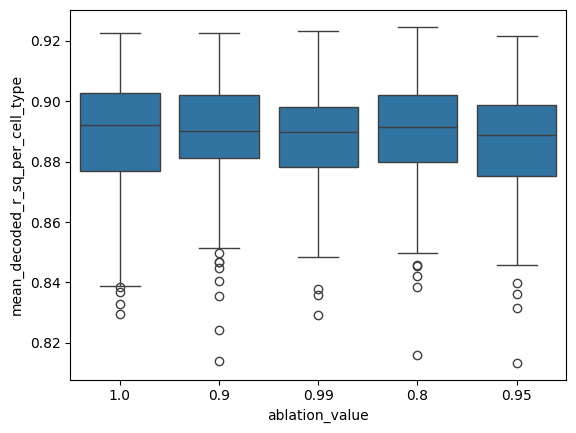

In [23]:
sns.boxplot(df, x="ablation_value", y="mean_decoded_r_sq_per_cell_type")

In [24]:
df.groupby("ablation_value").count()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_B Intermediate/Memory,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,...,deg_decoded_r_squared_CD16 Mono,deg_decoded_r_squared_CD56-bright NK,deg_decoded_r_squared_MAIT,deg_decoded_r_squared_Treg,deg_decoded_r_squared_NKT,deg_decoded_r_squared_pDC,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train
ablation_value,,,,,,,,,,,,,,,,,,,,,
0.8,170,170,170,170,170,170,170,170,170,170,...,170,170,170,170,153,153,170,170,170,170
0.9,190,190,190,190,190,190,190,190,190,190,...,190,190,190,190,171,171,190,190,190,190
0.95,150,150,150,150,150,150,150,150,150,150,...,150,150,150,150,135,135,150,150,150,150
0.99,140,140,140,140,140,140,140,140,140,140,...,140,140,140,140,126,126,140,140,140,140
1.0,190,190,190,190,190,190,190,190,190,190,...,190,190,190,190,171,171,190,190,190,190


In [25]:
df["cytokine_in_train"] = df["cytokine_in_train"].astype("float")
df.groupby("ablation_value")["cytokine_in_train"].mean()

ablation_value
0.8     32.647059
0.9     31.473684
0.95    23.000000
0.99    22.714286
1.0     30.210526
Name: cytokine_in_train, dtype: float64

In [26]:
df.columns

Index(['mean_decoded_r_sq_per_cell_type', 'mean_e_distance_per_cell_type',
       'mean_deg_r_sq_per_cell_type', 'decoded_r_squared_CD8 Naive',
       'decoded_r_squared_B Naive', 'decoded_r_squared_B Intermediate/Memory',
       'decoded_r_squared_CD14 Mono', 'decoded_r_squared_CD4 Naive',
       'decoded_r_squared_CD56-dim NK', 'decoded_r_squared_CD4 Memory',
       'decoded_r_squared_cDC', 'decoded_r_squared_CD8 Memory',
       'decoded_r_squared_CD16 Mono', 'decoded_r_squared_CD56-bright NK',
       'decoded_r_squared_MAIT', 'decoded_r_squared_Treg',
       'decoded_r_squared_NKT', 'decoded_r_squared_pDC',
       'e_distance_CD8 Naive', 'e_distance_B Naive',
       'e_distance_B Intermediate/Memory', 'e_distance_CD14 Mono',
       'e_distance_CD4 Naive', 'e_distance_CD56-dim NK',
       'e_distance_CD4 Memory', 'e_distance_cDC', 'e_distance_CD8 Memory',
       'e_distance_CD16 Mono', 'e_distance_CD56-bright NK', 'e_distance_MAIT',
       'e_distance_Treg', 'e_distance_NKT', 'e_dist

In [27]:
df.shape

(840, 53)